# Task 1: Diagnostic Enhancement of Chest X-Rays

**Scenario:** Junior computational researcher at a pulmonary imaging lab.
Raw X-rays are severely underexposed — lung cavities and potential fluid build-up are nearly invisible.
We apply a full mathematical enhancement pipeline to maximize structural visibility.


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('output', exist_ok=True)

## Step 1: Load and Display the Raw X-Ray

Shape: (232, 232), dtype: uint8
Pixel range: [0, 255]


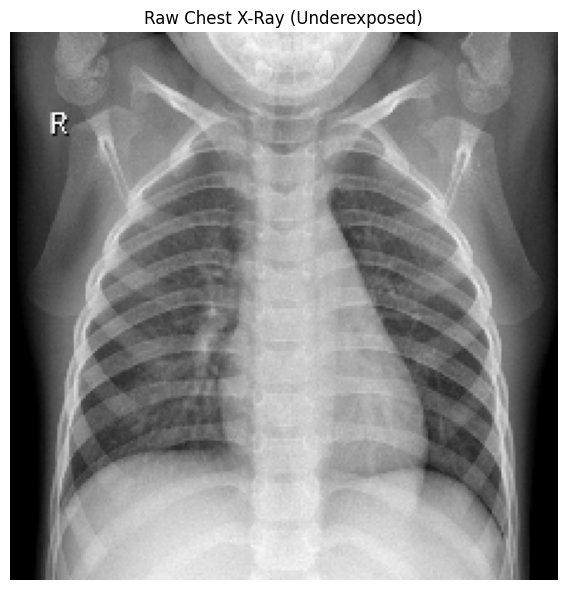

Saved -> output/01_raw_xray.png


In [2]:
# load grayscale -- x-rays are single channel, no need for BGR
img_raw = cv2.imread('data/sample_xray.png', cv2.IMREAD_GRAYSCALE)

if img_raw is None:
    raise FileNotFoundError("Place a chest X-ray image at data/sample_xray.png")

print(f'Shape: {img_raw.shape}, dtype: {img_raw.dtype}')
print(f'Pixel range: [{img_raw.min()}, {img_raw.max()}]')

plt.figure(figsize=(6,6))
plt.imshow(img_raw, cmap='gray')
plt.title('Raw Chest X-Ray (Underexposed)')
plt.axis('off')
plt.tight_layout()
plt.savefig('output/01_raw_xray.png', dpi=150)
plt.show()
print('Saved -> output/01_raw_xray.png')

## Step 2: Contrast Enhancement via Histogram Equalization

Histogram equalization redistributes pixel intensities across the full 0-255 range,
forcing faint structures like lung walls and fluid boundaries to become visible.

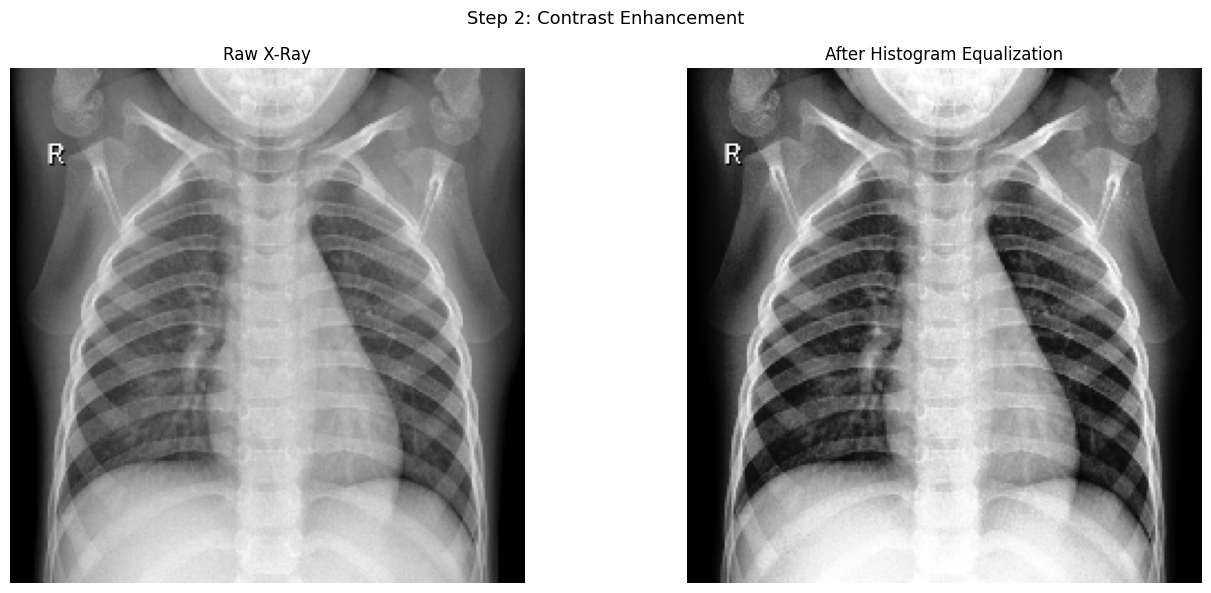

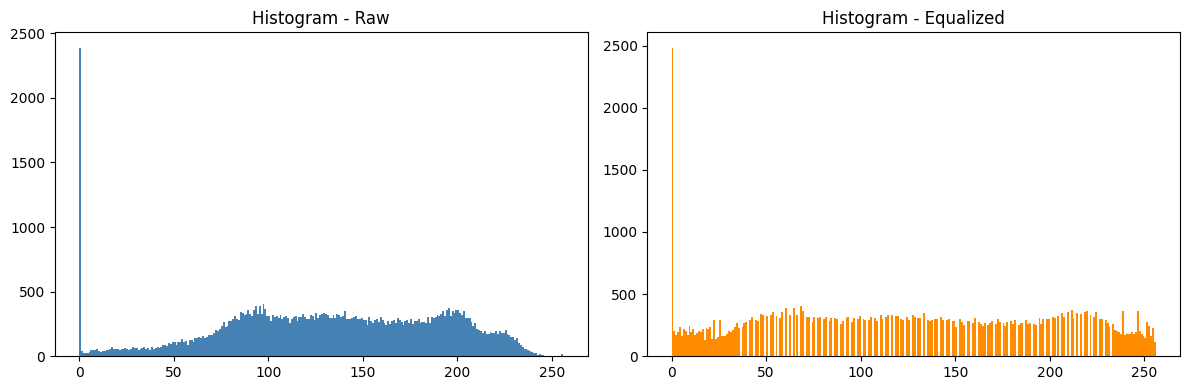

Saved -> output/02_histogram_equalization.png, output/02b_histograms.png


In [3]:
# equalizeHist remaps the cumulative distribution to be uniform
img_eq = cv2.equalizeHist(img_raw)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title('Raw X-Ray')
axes[0].axis('off')
axes[1].imshow(img_eq, cmap='gray')
axes[1].set_title('After Histogram Equalization')
axes[1].axis('off')
plt.suptitle('Step 2: Contrast Enhancement', fontsize=13)
plt.tight_layout()
plt.savefig('output/02_histogram_equalization.png', dpi=150)
plt.show()

# also plot the histograms to visualize the redistribution
fig2, ax2 = plt.subplots(1,2, figsize=(12,4))
ax2[0].hist(img_raw.ravel(), bins=256, range=(0,256), color='steelblue')
ax2[0].set_title('Histogram - Raw')
ax2[1].hist(img_eq.ravel(), bins=256, range=(0,256), color='darkorange')
ax2[1].set_title('Histogram - Equalized')
plt.tight_layout()
plt.savefig('output/02b_histograms.png', dpi=150)
plt.show()
print('Saved -> output/02_histogram_equalization.png, output/02b_histograms.png')

## Step 3: False-Color Heatmap (COLORMAP_JET)

The eye distinguishes color much better than shades of gray.
Mapping intensity to a color spectrum makes subtle fluid boundaries pop as different hues.
Low intensity = blue, mid = green/yellow, high = red.

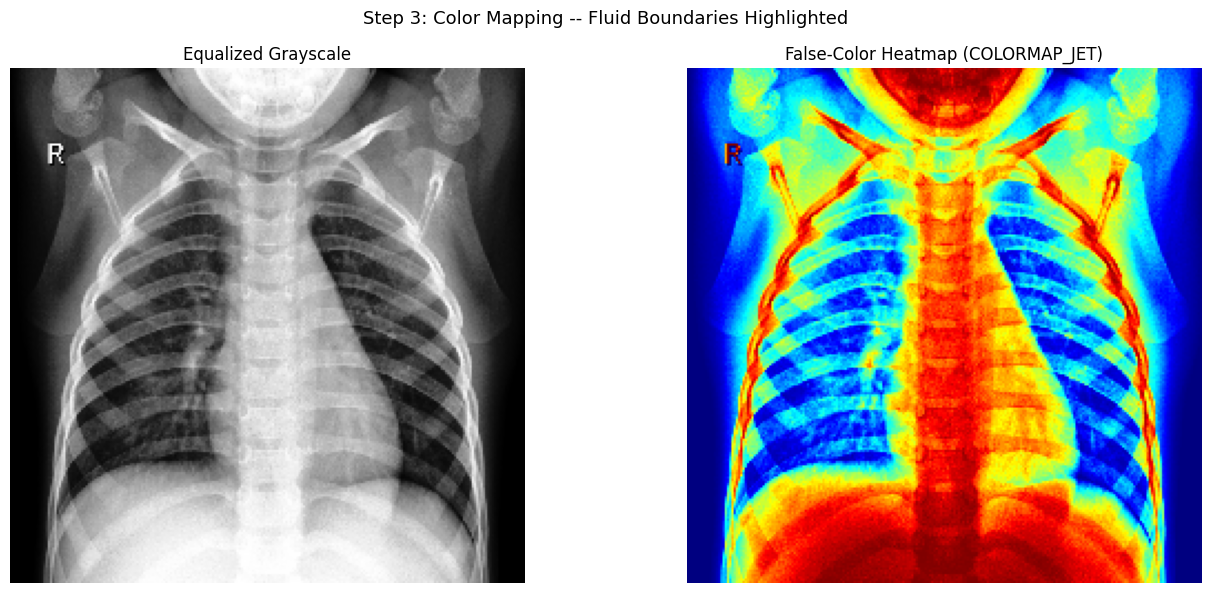

Saved -> output/03_colormap_jet.png


In [4]:
# apply COLORMAP_JET -- converts single-channel matrix to 3-channel BGR heatmap
img_heatmap = cv2.applyColorMap(img_eq, cv2.COLORMAP_JET)
img_heatmap_rgb = cv2.cvtColor(img_heatmap, cv2.COLOR_BGR2RGB)  # flip to RGB for matplotlib

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(img_eq, cmap='gray')
axes[0].set_title('Equalized Grayscale')
axes[0].axis('off')
axes[1].imshow(img_heatmap_rgb)
axes[1].set_title('False-Color Heatmap (COLORMAP_JET)')
axes[1].axis('off')
plt.suptitle('Step 3: Color Mapping -- Fluid Boundaries Highlighted', fontsize=13)
plt.tight_layout()
plt.savefig('output/03_colormap_jet.png', dpi=150)
plt.show()
print('Saved -> output/03_colormap_jet.png')

## Step 4: Color Balance Correction

The JET colormap can introduce an artificial color cast depending on the pixel distribution.
We use a gray-world assumption: scale each channel so all three share the same mean.
This neutralizes any tint while preserving the structural color information.

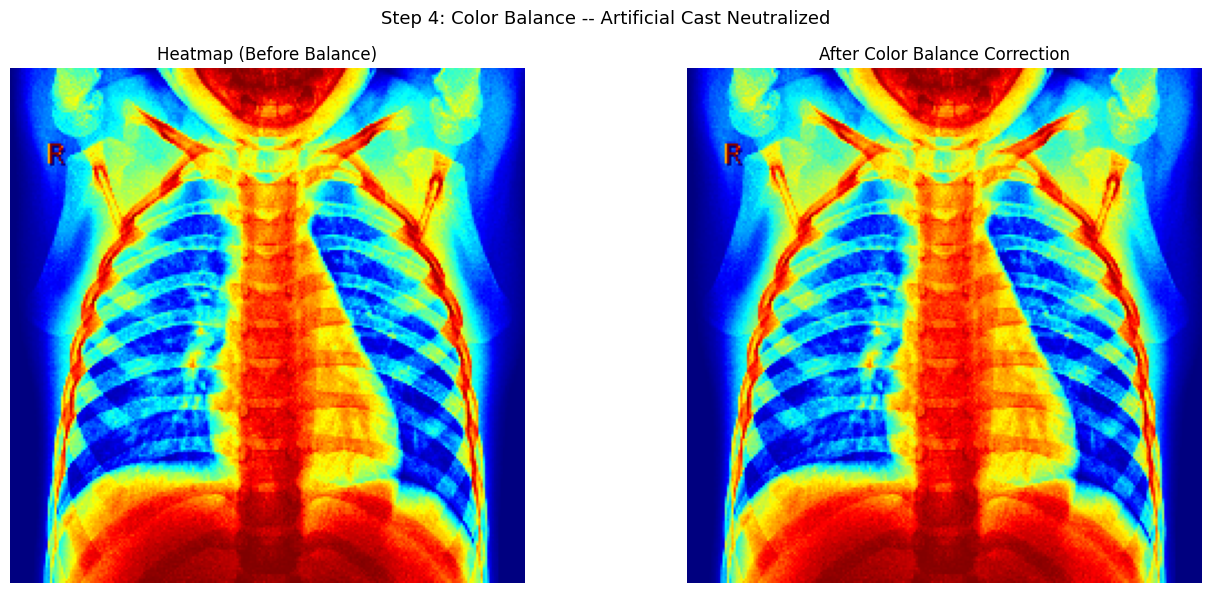

Saved -> output/04_color_balance.png


In [5]:
def color_balance(img_bgr):
    """Gray-world color balance: each channel is scaled to match the global average intensity."""
    result = img_bgr.astype(np.float32)
    global_mean = result.mean()
    for ch in range(3):
        ch_mean = result[:, :, ch].mean()
        if ch_mean > 0:
            result[:, :, ch] *= (global_mean / ch_mean)
    return np.clip(result, 0, 255).astype(np.uint8)

img_balanced = color_balance(img_heatmap)
img_balanced_rgb = cv2.cvtColor(img_balanced, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(img_heatmap_rgb)
axes[0].set_title('Heatmap (Before Balance)')
axes[0].axis('off')
axes[1].imshow(img_balanced_rgb)
axes[1].set_title('After Color Balance Correction')
axes[1].axis('off')
plt.suptitle('Step 4: Color Balance -- Artificial Cast Neutralized', fontsize=13)
plt.tight_layout()
plt.savefig('output/04_color_balance.png', dpi=150)
plt.show()
print('Saved -> output/04_color_balance.png')

## Step 5: Color Filtering / Thresholding -- Isolate Dense Tissue

Dense tissues (bone, consolidated fluid) produce the highest intensities.
A strict binary threshold zeros out everything below the cutoff,
leaving only those peak-intensity regions visible as a mask.

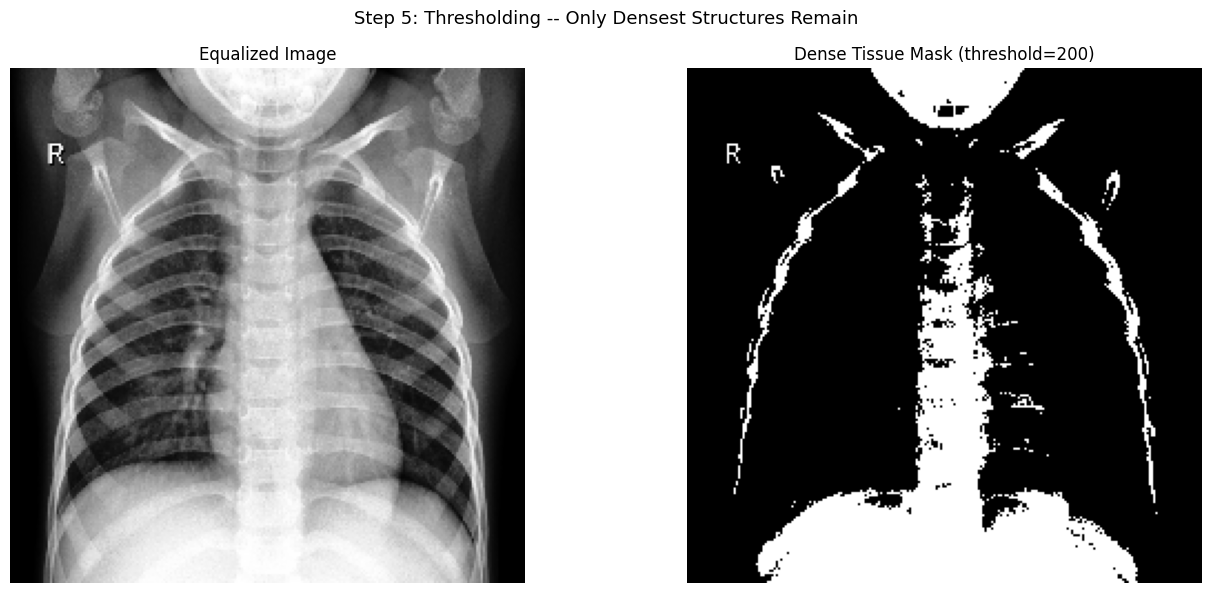

Saved -> output/05_thresholding.png


In [6]:
# anything below this intensity threshold gets wiped to black
THRESHOLD = 200

_, img_thresh = cv2.threshold(img_eq, THRESHOLD, 255, cv2.THRESH_BINARY)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(img_eq, cmap='gray')
axes[0].set_title('Equalized Image')
axes[0].axis('off')
axes[1].imshow(img_thresh, cmap='gray')
axes[1].set_title(f'Dense Tissue Mask (threshold={THRESHOLD})')
axes[1].axis('off')
plt.suptitle('Step 5: Thresholding -- Only Densest Structures Remain', fontsize=13)
plt.tight_layout()
plt.savefig('output/05_thresholding.png', dpi=150)
plt.show()
print('Saved -> output/05_thresholding.png')

## Step 6: Logarithmic Transformation

Log transform compresses bright pixels and expands dark ones.
Applied to the raw underexposed image, it pulls out faint outer structures
(ribcage edges) that would otherwise stay invisible.

Formula: output = c * log(1 + pixel)

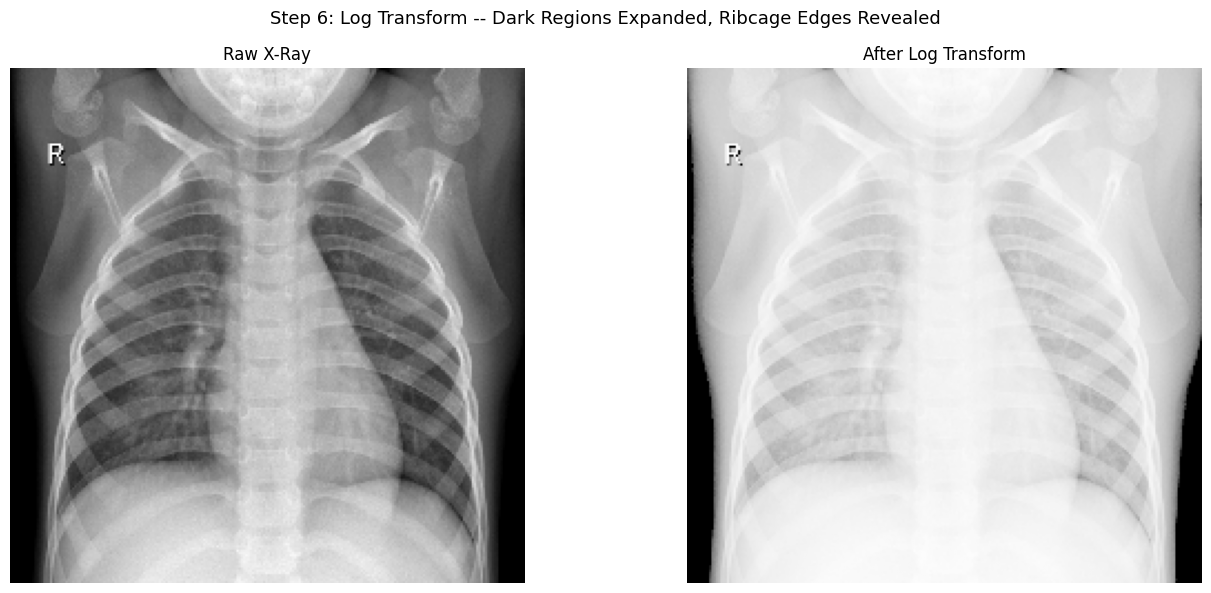

Saved -> output/06_log_transform.png


In [7]:
img_float = img_raw.astype(np.float32)

# log1p = log(1 + x), safe for x=0
img_log = np.log1p(img_float)

# scale back to 0-255
c = 255.0 / np.log1p(255.0)
img_log_scaled = np.clip(c * img_log, 0, 255).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14,6))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title('Raw X-Ray')
axes[0].axis('off')
axes[1].imshow(img_log_scaled, cmap='gray')
axes[1].set_title('After Log Transform')
axes[1].axis('off')
plt.suptitle('Step 6: Log Transform -- Dark Regions Expanded, Ribcage Edges Revealed', fontsize=13)
plt.tight_layout()
plt.savefig('output/06_log_transform.png', dpi=150)
plt.show()
print('Saved -> output/06_log_transform.png')

## Step 7: Power-Law (Gamma) Transformation

Gamma < 1.0 bends the curve upward, brightening midtones.
This reduces the harsh contrast of bone so the soft lung tissue underneath becomes clearer.

Formula: output = (pixel/255)^gamma * 255

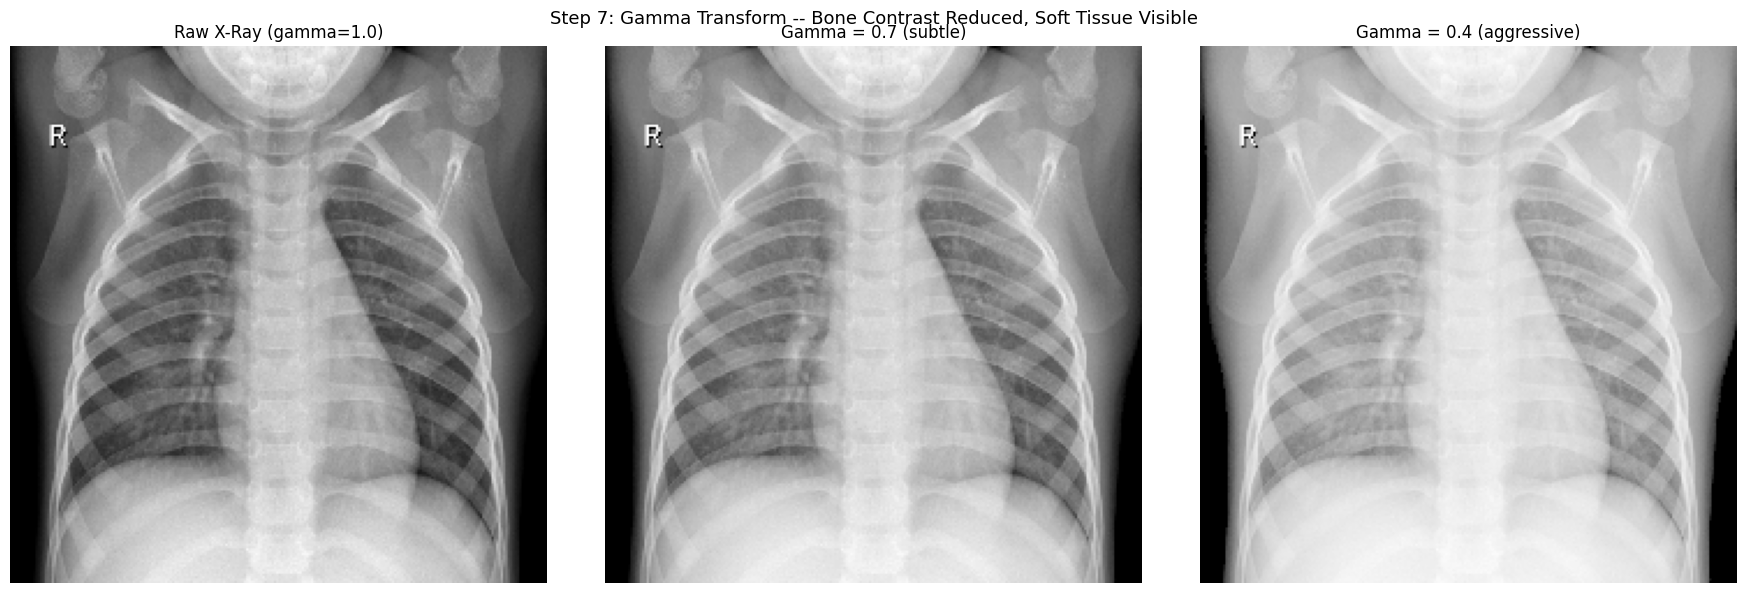

Saved -> output/07_gamma_transform.png


In [8]:
def apply_gamma(img_gray, gamma):
    """Fractional gamma (gamma < 1) lifts midtones to reveal soft tissue structure."""
    normalized = img_gray.astype(np.float32) / 255.0
    corrected = np.power(normalized, gamma)
    return np.clip(corrected * 255.0, 0, 255).astype(np.uint8)

img_gamma_04 = apply_gamma(img_raw, 0.4)  # aggressive -- lots of midtone lift
img_gamma_07 = apply_gamma(img_raw, 0.7)  # subtle -- gentle correction

fig, axes = plt.subplots(1, 3, figsize=(18,6))
axes[0].imshow(img_raw, cmap='gray')
axes[0].set_title('Raw X-Ray (gamma=1.0)')
axes[0].axis('off')
axes[1].imshow(img_gamma_07, cmap='gray')
axes[1].set_title('Gamma = 0.7 (subtle)')
axes[1].axis('off')
axes[2].imshow(img_gamma_04, cmap='gray')
axes[2].set_title('Gamma = 0.4 (aggressive)')
axes[2].axis('off')
plt.suptitle('Step 7: Gamma Transform -- Bone Contrast Reduced, Soft Tissue Visible', fontsize=13)
plt.tight_layout()
plt.savefig('output/07_gamma_transform.png', dpi=150)
plt.show()
print('Saved -> output/07_gamma_transform.png')

## Final: Full Pipeline Summary

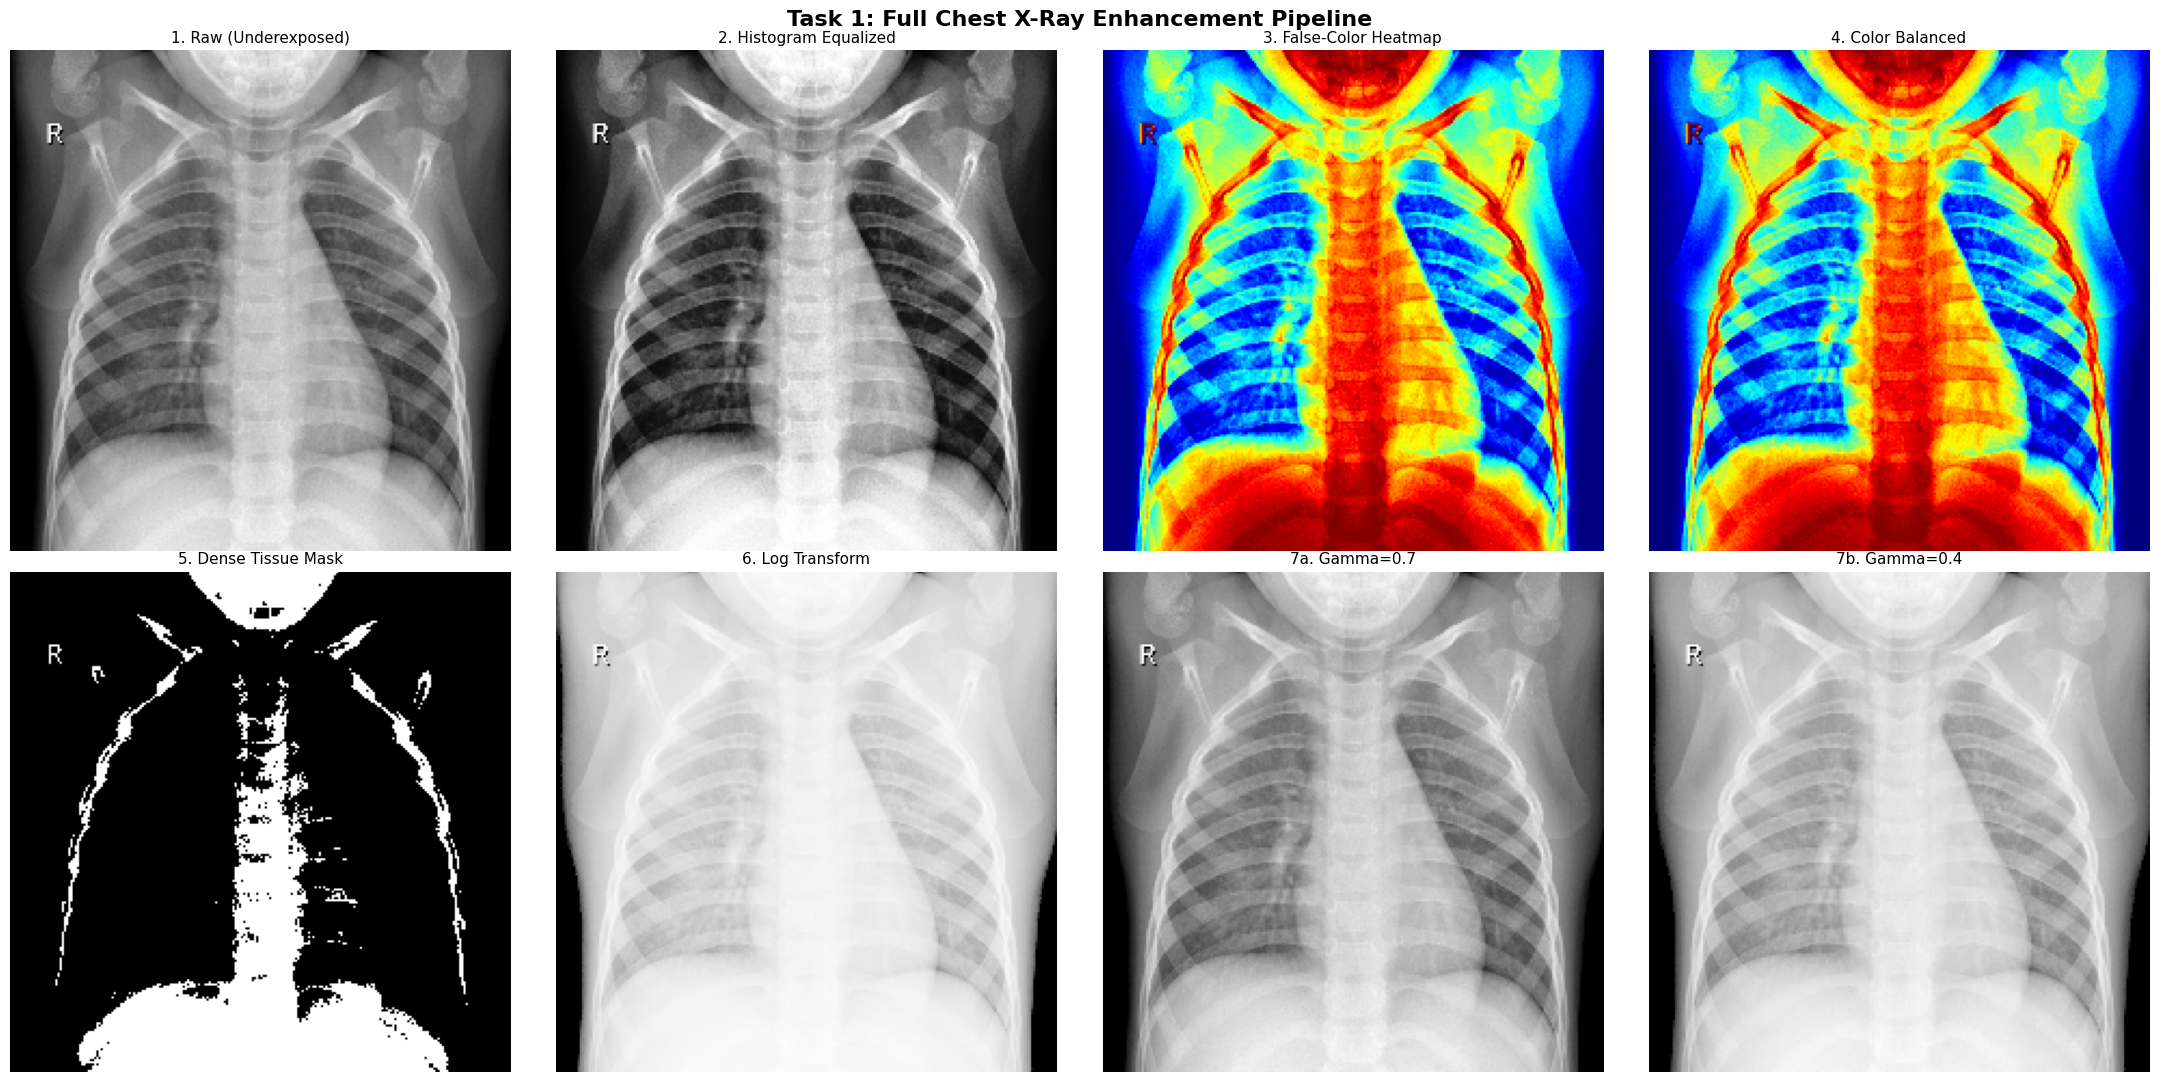

All done! Outputs saved to output/


In [9]:
fig, axes = plt.subplots(2, 4, figsize=(22,11))
fig.suptitle('Task 1: Full Chest X-Ray Enhancement Pipeline', fontsize=16, fontweight='bold')

panels = [
    (img_raw,          'gray',  '1. Raw (Underexposed)'),
    (img_eq,           'gray',  '2. Histogram Equalized'),
    (img_heatmap_rgb,  None,    '3. False-Color Heatmap'),
    (img_balanced_rgb, None,    '4. Color Balanced'),
    (img_thresh,       'gray',  '5. Dense Tissue Mask'),
    (img_log_scaled,   'gray',  '6. Log Transform'),
    (img_gamma_07,     'gray',  '7a. Gamma=0.7'),
    (img_gamma_04,     'gray',  '7b. Gamma=0.4'),
]

for ax, (im, cmap, title) in zip(axes.ravel(), panels):
    ax.imshow(im, cmap=cmap) if cmap else ax.imshow(im)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

plt.tight_layout()
plt.savefig('output/00_full_pipeline_summary.png', dpi=150)
plt.show()
print('All done! Outputs saved to output/')